Chapter 23
# 用Pandas + Plotly讲故事
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
# 导入包
import seaborn as sns
import pandas as pd
import plotly.express as px

In [2]:
# 使用Seaborn加载鸢尾花数据集
df = sns.load_dataset("iris")

In [40]:
 ! python -m pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 27.6 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [41]:
 ! pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 933.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.8 MB/s eta 0:00:00


In [42]:
import plotly.io as pio

In [5]:
df_ = df.copy()
df_["species_numerical"] = df_["species"].map(
    {"setosa": 0, "versicolor": 1, "virginica": 2})

In [7]:
df_

,sepal_length,sepal_width,petal_length,petal_width,species,species_numerical
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2
146,6.3,2.5,5.0,1.9,virginica,2
147,6.5,3.0,5.2,2.0,virginica,2
148,6.2,3.4,5.4,2.3,virginica,2


第一个参数 df 为鸢尾花数据集，数据格式为 Pandas DataFrame。
然后利用两个关键字参数指定横纵轴特征。数据集 df 中的 sepal_length 列作为 x 轴数
据，petal_length 列作为 y 轴数据。
关键字参数 color='species'指定了渲染编码的依据，即根据数据集中的 'species' 列的不
同取值来区分不同种类的鸢尾花。
两个参数，marginal_x='box' 和 marginal_y='box'，分别表示在 x 轴和 y 轴的边缘添
加一个箱型图，用于显示数据在每个轴上的分布情况。
Plotly 散点图还提供其他边缘分布的可视化方案，比如直方图"histogram"、毛毯图"rug"、
小提琴图"violin"等，请大家练习使用。
参数 template="plotly_white" 设置了图片对象的主题风格，即使用"plotly_white"这种
白色背景设计。
width=600 和 height=500 这两个参数分别设置了图表的宽度和高度，以像素为单位。

color_discrete_sequence=px.colors.qualitative.Pastel1 指定了颜色映射的调色
板，即使用 Plotly Express 模块中提供的"Pastel1"调色板，以一组柔和的颜色来表示不同种类的
花。
labels={"sepal_length": "Sepal Length (cm)", "petal_length": "Petal
length (cm)"} 用于自定义图表的标签，将 x 轴标签设置为 "Sepal Length (cm)"，将 y 轴
标签设置为 "Petal length (cm)"。


In [8]:
# 用plotly绘制散点图，边缘为箱型图，分类为 species
fig = px.scatter(df, x = 'sepal_length', y = 'petal_length',
                 color = 'species', marginal_x = 'box',
                 marginal_y = 'box', template = "plotly_white",
                 width=600, height=500,
                 color_discrete_sequence=px.colors.qualitative.Pastel1,
                 labels={"sepal_length": "Sepal Length (cm)",
                         "petal_length": "Petal length (cm)"})
fig.show()
# pio.write_image(fig, '鸢尾花，散点，box.svg')

In [10]:
# 绘制成对散点图
fig = px.scatter_matrix(df_,
                        dimensions=["sepal_length", "sepal_width",
                                    "petal_length", "petal_width",
                                    "species"],
                        template = "plotly_white",
                        color = 'species', width = 600, height = 600)
fig.update_traces(diagonal_visible=False)
fig.show()
# pio.write_image(fig, '1.svg')
'''
调用 plotly.express.scatter_matrix()，参数 dimensions 用来指定散点图的维度。
注意，不同于 seaborn.pairplot()，plotly.express.scatter_matrix() 可以展示分类
数据。
将对角线子图设为不可见。diagonal_visible=False
'''


In [11]:
# 用花萼长度 * 花萼宽度，代表花萼面积
df['area'] = df['sepal_length'] * df['sepal_width']

# 用花萼面积大小将样本等分为数量 (大致) 相等的5个区间
df['Category'] = pd.qcut(df['area'], 5, labels = ['A','B','C','D','E'])
#然后，根据“花萼面积”的大小将 150 个样本数据
#几乎均匀地分成 5 个类别，并分别给它们新的标签 A、B、C、D、E，这一列列标签命名为'Category'。


In [12]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,area,Category
0,5.1,3.5,1.4,0.2,setosa,17.85,C
1,4.9,3.0,1.4,0.2,setosa,14.70,A
2,4.7,3.2,1.3,0.2,setosa,15.04,B
3,4.6,3.1,1.5,0.2,setosa,14.26,A
4,5.0,3.6,1.4,0.2,setosa,18.00,C
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,20.10,D
146,6.3,2.5,5.0,1.9,virginica,15.75,B
147,6.5,3.0,5.2,2.0,virginica,19.50,D
148,6.2,3.4,5.4,2.3,virginica,21.08,E


In [13]:
import numpy as np
# 按区间汇总 (最小值，最大值，均值，标准差）
list_stats = ['min', 'max', 'mean', 'median', 'std', np.mean]
stats_by_area = df.groupby('Category')['area'].agg(list_stats)

# 计算极差，最大值 - 最小值
stats_by_area['Range'] = stats_by_area['max'] - stats_by_area['min']
# 每个区间的样本数量
stats_by_area['Number'] = df['Category'].value_counts()

/tmp/ipykernel_1114/3179125846.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1114/3179125846.py:4: FutureWarning:

The provided callable <function mean at 0x79e3c5f363e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



核心原因
当你执行 df.groupby('Category')['area'] 时，Pandas 只是准备好了分组规则，但并没有执行任何计算。它处于一种“惰性求值”（Lazy Evaluation）状态，等待你告诉它下一步要做什么。

这类似于你在餐厅已经点好了菜（告诉厨师按类别分组），但还没告诉厨师要怎么做（是炒、蒸还是煮），所以厨房里不会有成品端出来。

它到底是什么？
df.groupby('Category')['area'] 返回的是一个 SeriesGroupBy 对象，而不是一个 Series 或 DataFrame。

python
result = df.groupby('Category')['area']
print(type(result))  


```
输出：<class 'pandas.core.groupby.generic.SeriesGroupBy'>
```


这个对象里面存储了：

分组依据（'Category'）

要操作的数据列（'area'）

各个分组的数据索引映射

但它没有具体数值，只是一套“操作指令”。

In [18]:
result = df.groupby('Category')['area']
print(type(result))


<class 'pandas.core.groupby.generic.SeriesGroupBy'>


/tmp/ipykernel_1114/3193808728.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [14]:
stats_by_area

,min,max,mean,median,std,mean,Range,Number
Category,,,,,,,,
A,10.00,15.00,13.421667,13.695,1.278288,13.421667,5.00,30
B,15.04,16.80,15.912000,15.910,0.540532,15.912000,1.76,30
C,16.83,18.30,17.623226,17.680,0.436023,17.623226,1.47,31
D,18.36,20.77,19.701379,19.610,0.728044,19.701379,2.41,29
E,20.79,30.02,22.525333,21.630,2.274115,22.525333,9.23,30


In [19]:
stats_by_area.to_csv('stats_by_area.csv')

In [21]:
df

,sepal_length,sepal_width,petal_length,petal_width,species,area,Category
0,5.1,3.5,1.4,0.2,setosa,17.85,C
1,4.9,3.0,1.4,0.2,setosa,14.70,A
2,4.7,3.2,1.3,0.2,setosa,15.04,B
3,4.6,3.1,1.5,0.2,setosa,14.26,A
4,5.0,3.6,1.4,0.2,setosa,18.00,C
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,20.10,D
146,6.3,2.5,5.0,1.9,virginica,15.75,B
147,6.5,3.0,5.2,2.0,virginica,19.50,D
148,6.2,3.4,5.4,2.3,virginica,21.08,E


In [20]:
# 用plotly绘制散点图，维度为面积，分类为Category
fig = px.scatter(df, x = 'area', y = 'Category',
                 color = 'Category',
                 template = "plotly_white",
                 width=600, height=300,
                 color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.show()
# pio.write_image(fig, 'plotly绘制散点图，维度为面积，分类为Category.svg')

In [22]:
# 用plotly绘制散点图，边缘为箱型图，分类为 Category
fig = px.scatter(df, x = 'sepal_length', y = 'petal_length',
                 color = 'Category', marginal_x = 'box',
                 marginal_y = 'box', template = "plotly_white",
                 width=600, height=500,
                 color_discrete_sequence=px.colors.qualitative.Pastel1,
                 labels={"sepal_length": "Sepal Length (cm)",
                         "petal_length": "Petal length (cm)"})
fig.show()
# pio.write_image(fig, '鸢尾花，散点，box, Category.svg')

In [24]:
import matplotlib.pyplot as plt

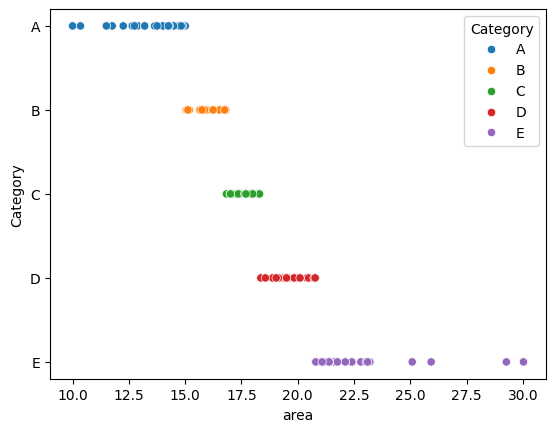

In [25]:
# 散点可视化不同类别花萼面积
sns.scatterplot(data = df, x = 'area', y = 'Category', hue = 'Category')
plt.savefig('area, category.svg')

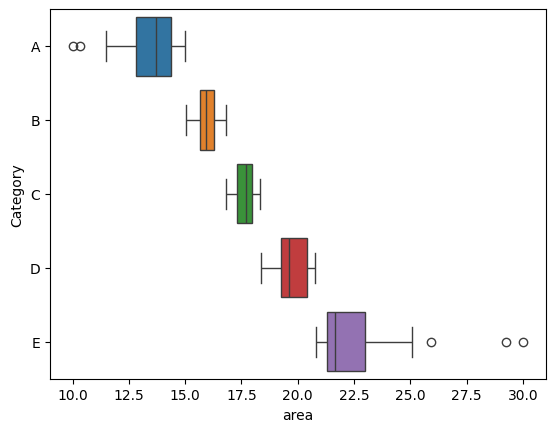

In [26]:
# 箱型图可视化不同类别花萼面积
sns.boxplot(data = df, x = 'area', y = 'Category', hue = 'Category')
plt.savefig('box, area, category.svg')

In [27]:
fig = px.box(df, x = 'area', y = 'Category',
             color = 'Category', points="all",
             template = "plotly_white",
             width=600, height=300,
             color_discrete_sequence=px.colors.qualitative.Pastel1)
fig.show()
# pio.write_image(fig, 'plotly绘制箱型图，边缘为箱型图.svg')

逐参数详解
1. fig = px.box(df, ...)
调用 Plotly Express 的 box() 函数创建箱线图

df：数据源（DataFrame）

2. x = 'sepal_length', y = 'Category'
x 轴：使用 sepal_length 列作为数值变量（箱线图的统计对象）

y 轴：使用 Category 列作为分组变量（每个类别画一个箱线图）

因为箱线图默认是垂直的（x 轴为类别，y 轴为数值），但这里把数值放在 x 轴、类别放在 y 轴，所以实际效果是水平箱线图。

3. color = 'Category'
根据 Category 列的值给每个类别的箱线图赋予不同颜色

不同类别的箱子颜色不同，便于区分

4. points="all"
显示所有原始数据点（散点图形式）

可选值：

"all"：显示所有数据点

"outliers"：只显示异常值（默认）

"suspectedoutliers"：显示疑似异常值

False：不显示任何点

每个数据点会叠加在箱线图上，帮助你看到数据的实际分布情况。

5. template = "plotly_white"
使用预设的图表主题风格

"plotly_white" 是白色背景、简洁风格的模板

其他常用模板：

"plotly"：默认深色背景

"ggplot2"：类似 R 语言 ggplot2 风格

"seaborn"：类似 Seaborn 风格

"simple_white"：极简白色

6. width=600, height=300
设置图表的宽度为 600 像素，高度为 300 像素

适合嵌入报告或仪表板，尺寸紧凑

7. category_orders={"Category": ["A", "B", "C", "D", "E"]}
强制指定 Y 轴上类别的显示顺序

即使数据中类别顺序混乱，图表会按 A → B → C → D → E 从上到下排列

这对保持图表一致性非常重要（比如多张图对比时）

8. color_discrete_sequence=px.colors.qualitative.Pastel1
自定义颜色序列，使用柔和的粉彩色系

px.colors.qualitative.Pastel1 是一组预定义的柔和颜色调色板

其他可选调色板：

px.colors.qualitative.Set1（鲜艳）

px.colors.qualitative.Dark2（深色）

px.colors.qualitative.Paired（配对色）

9. labels={"sepal_length": "Sepal Length (cm)"}
重命名轴标签，将 x 轴的显示名称从 sepal_length 改为 "Sepal Length (cm)"

这样图表更专业、易读，不需要在数据源中修改列名

10. fig.show()
在浏览器或 Jupyter Notebook 中渲染并显示图表

这是 Plotly 的交互式展示方法，支持缩放、悬停查看数据等操作

In [28]:
# 花萼长度的箱型图，考虑'Category'分类
fig = px.box(df, x = 'sepal_length', y = 'Category',
             color = 'Category', points="all",
             template = "plotly_white",
             width=600, height=300,
             category_orders={"Category": ["A", "B", "C", "D", "E"]},
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             labels={"sepal_length": "Sepal Length (cm)"})
fig.show()
# pio.write_image(fig, 'plotly绘制箱型图，边缘为箱型图.svg')

In [29]:
# 从Category和species两个维度切割鸢尾花数据，结果为二维频率
freq_matrix = pd.crosstab(index = df['Category'],
                          columns = df['species'])

In [30]:
freq_matrix

species,setosa,versicolor,virginica
Category,,,
A,12,15,3
B,10,13,7
C,12,9,10
D,9,10,10
E,7,3,20


In [32]:
freq_matrix.index

CategoricalIndex(['A', 'B', 'C', 'D', 'E'], categories=['A', 'B', 'C', 'D', 'E'], ordered=True, dtype='category', name='Category')

In [31]:
freq_matrix.columns

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='species')

In [33]:
# 可视化二元频率数组
fig = px.imshow(freq_matrix, text_auto=True)
fig.show()
# pio.write_image(fig, '频率，热图.svg')

不同的是参数 normalize = 'all' 指定标准化的方法，'all' 表示对整个交叉
制表进行标准化，将每个频数除以样本数总和，得到概率值。这就是为什么图 6 (b) 中热图所有格子
值的总和为 1。

In [34]:
# 从Category和species两个维度切割鸢尾花数据，结果为二维频率
prob_matrix = pd.crosstab(index = df['Category'],
                          columns = df['species'],
                          normalize = 'all')


In [36]:
prob_matrix

species,setosa,versicolor,virginica
Category,,,
A,0.080000,0.100000,0.020000
B,0.066667,0.086667,0.046667
C,0.080000,0.060000,0.066667
D,0.060000,0.066667,0.066667
E,0.046667,0.020000,0.133333


In [37]:
# pandas.DataFrame.value_counts
df['Category'].value_counts().sort_index()

,count
Category,
A,30
B,30
C,31
D,29
E,30


In [47]:
! pip install -U kaleido

In [49]:
# 可视化二元概率数组
#import plotly.io as pio
fig = px.imshow(prob_matrix, text_auto='.3f')
fig.show()
#pio.write_image(fig, '概率，热图.svg') 可能版本有问题

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


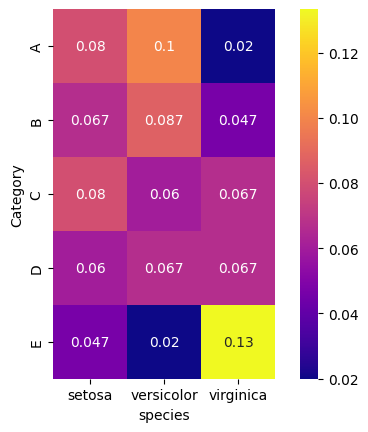

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(prob_matrix,cmap = 'plasma', square = True, annot = True)
plt.savefig('heatmap.svg')

In [51]:
prob_matrix

species,setosa,versicolor,virginica
Category,,,
A,0.080000,0.100000,0.020000
B,0.066667,0.086667,0.046667
C,0.080000,0.060000,0.066667
D,0.060000,0.066667,0.066667
E,0.046667,0.020000,0.133333


In [ ]:
# 绘制二维直方热图 + 边缘直方图，计数
fig = px.density_heatmap(df, x = 'species', y = 'Category',
                         category_orders={"Category": ["A", "B", "C", "D", "E"]},
                         marginal_x="histogram", marginal_y="histogram",
                         text_auto = True, width = 400, height = 500)
fig.show() #版本有问题

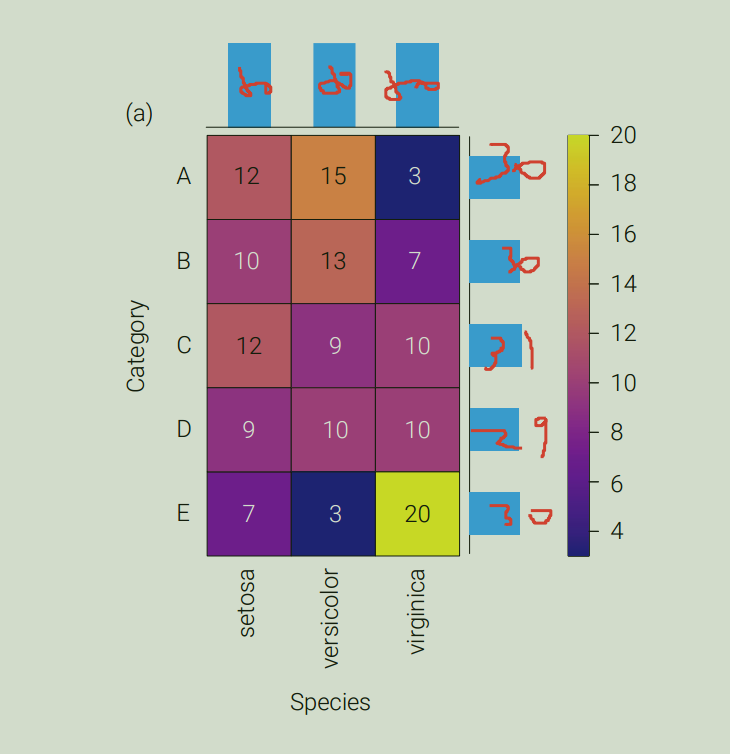

In [ ]:
# 绘制二维直方热图 + 边缘直方图，概率
fig = px.density_heatmap(df, x = 'species', y = 'Category',
                         category_orders={"Category": ["A", "B", "C", "D", "E"]},
                         marginal_x="histogram", marginal_y="histogram",
                         histnorm = 'probability',
                         text_auto='.3f', width = 400, height = 500)
#不同的是参数 histnorm='probability'指定直方图的标准化方法。设置为
#'probability' 表示热图中的数值标准化为概率密度。

fig.show()#版本有问题

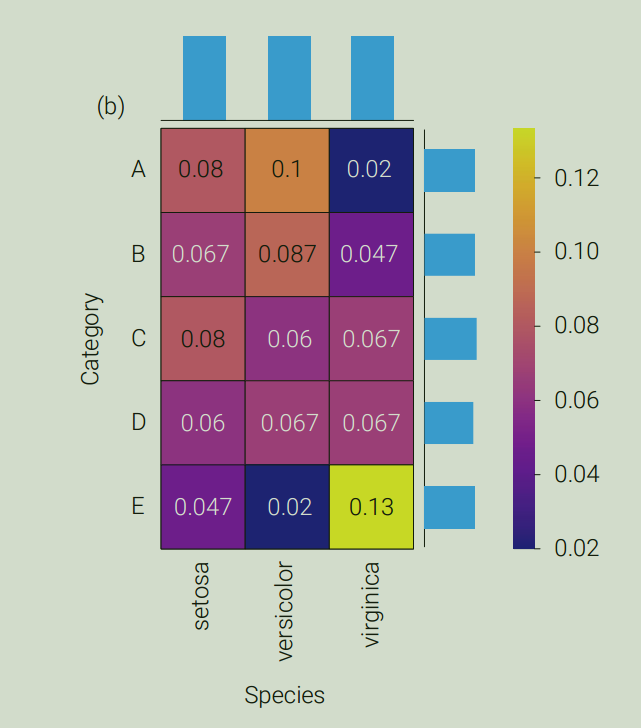

In [55]:
df['Category'].value_counts()

,count
Category,
C,31
A,30
B,30
E,30
D,29


In [61]:
import plotly
#print(plotly.__version__)
print(plotly.__file__)

/usr/local/lib/python3.12/dist-packages/plotly/__init__.py


In [62]:
import plotly.validators.histogram2d

In [63]:
import plotly.validators.histogram2d._xaxis

ModuleNotFoundError: No module named 'plotly.validators.histogram2d._xaxis'

其中，x="sepal_length" 和 y="sepal_width"这两个参数指定了在子图热
图中要显示的数据的 x 轴和 y 轴变量。
这两个参数，facet_row="Category" 和 facet_col="species"用于进行子图布置。
facet_row 将数据分成多行子图，每行对应于不同的 'Category' 值；facet_col 将数据分
成多列子图，每列对应于不同的 'species' 值。

In [58]:
# 绘制频率热图，子图布置
fig = px.density_heatmap(df,
                         x="sepal_length", y="sepal_width",
                         facet_row="Category", facet_col="species",
                         width = 500, height = 800, text_auto=True)
fig.show()
pio.write_image(fig, '2.svg')

ModuleNotFoundError: No module named 'plotly.validators.histogram2d._xaxis'

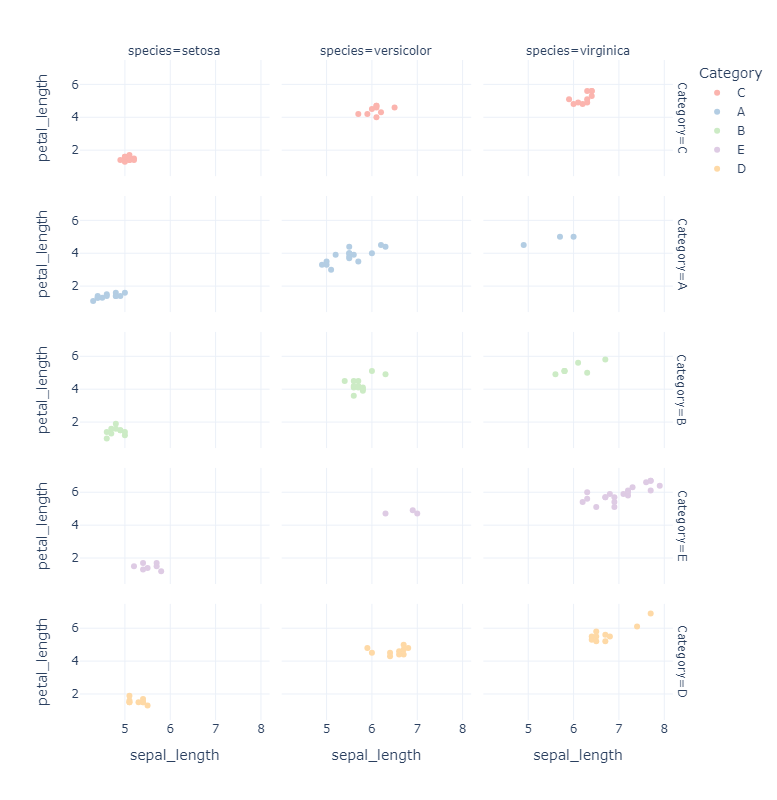

In [ ]:
fig = px.scatter(df,
                 x="sepal_length", y="petal_length",
                 template = "plotly_white",
                 color_discrete_sequence=px.colors.qualitative.Pastel1,
                 width = 700, height = 800,
                 color="Category", facet_col="species",
                 facet_row="Category")
fig.show()
pio.write_image(fig, '3.svg')

In [ ]:
# 计算 Category 百分比
ctg_percent = df['Category'].value_counts(normalize=True)
ctg_percent = pd.DataFrame({'Category':ctg_percent.index,
                            'Ratio':ctg_percent.values})
ctg_percent

,Category,Ratio
0,C,0.206667
1,A,0.200000
2,B,0.200000
3,E,0.200000
4,D,0.193333


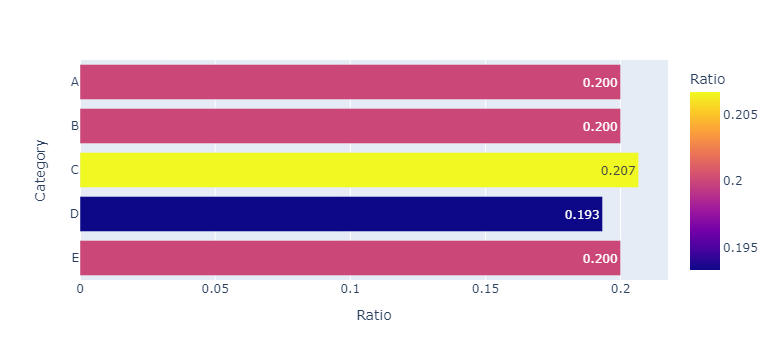

In [ ]:
# 用直方图展示 Category 分类比例
fig = px.bar(ctg_percent,
             x="Ratio", y="Category",
             category_orders={"Category": ["A", "B", "C", "D", "E"]},
             color = "Ratio", orientation='h',
             text_auto = '.3f')
fig.show()
pio.write_image(fig, '1.svg')

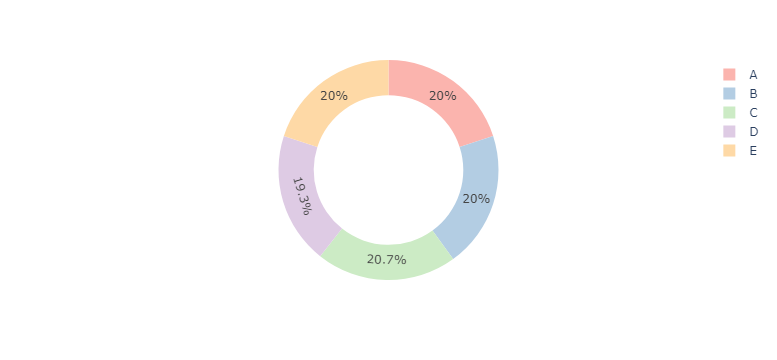

In [ ]:
# 用饼图可视化 'Category' 百分比
fig = px.pie(ctg_percent,
             category_orders={"Category": ["A", "B", "C", "D", "E"]},
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             values='Ratio', names='Category')
fig.update_traces(hole=.68)
fig.show()
pio.write_image(fig, '2.svg')

In [ ]:
# 计算 species 分类比例
species_percent = df['species'].value_counts(normalize=True)
species_percent = pd.DataFrame({'species':species_percent.index,
                                'Ratio':species_percent.values})
species_percent

,species,Ratio
0,setosa,0.333333
1,versicolor,0.333333
2,virginica,0.333333


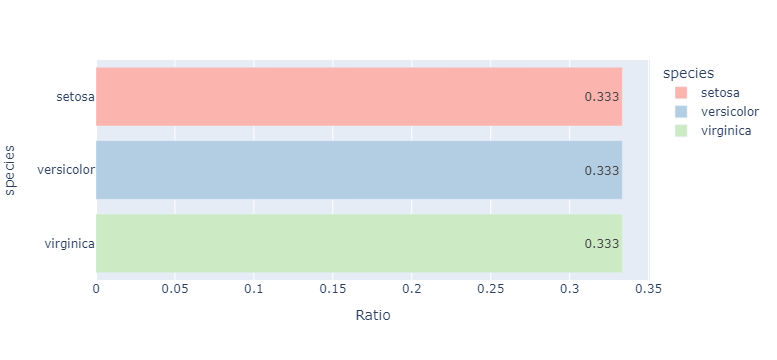

In [ ]:
# 用柱状图可视化 species 分类比例
fig = px.bar(species_percent,
             x="Ratio", y="species",
             category_orders={"species": ["setosa", "versicolor", "virginica"]},
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             color = "species", orientation='h',
             text_auto = '.3f')
fig.show()
pio.write_image(fig, '3.svg')

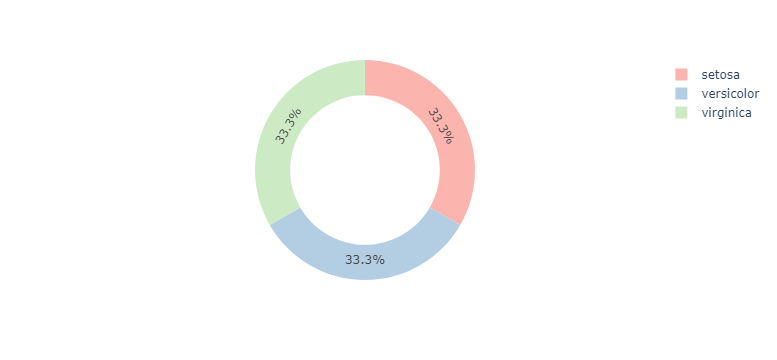

In [ ]:
# 用饼图可视化 species 分类百分比
fig = px.pie(species_percent,
             category_orders={"species": ["setosa", "versicolor", "virginica"]},
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             values='Ratio', names='species')
fig.update_traces(hole=.68)
fig.show()
pio.write_image(fig, '4.svg')

In [ ]:
# 绝对钻取

In [ ]:
# 将概率值 (比例值) stack 起来
prob_matrix_stacked = prob_matrix.stack().reset_index().rename(
    columns={0: "Ratio"})
prob_matrix_stacked


,Category,species,Ratio
0,A,setosa,0.080000
1,A,versicolor,0.100000
2,A,virginica,0.020000
3,B,setosa,0.066667
4,B,versicolor,0.086667
5,B,virginica,0.046667
6,C,setosa,0.080000
7,C,versicolor,0.060000
8,C,virginica,0.066667
9,D,setosa,0.060000


In [ ]:
prob_matrix_stacked.to_csv('prob_matrix_stacked.csv')

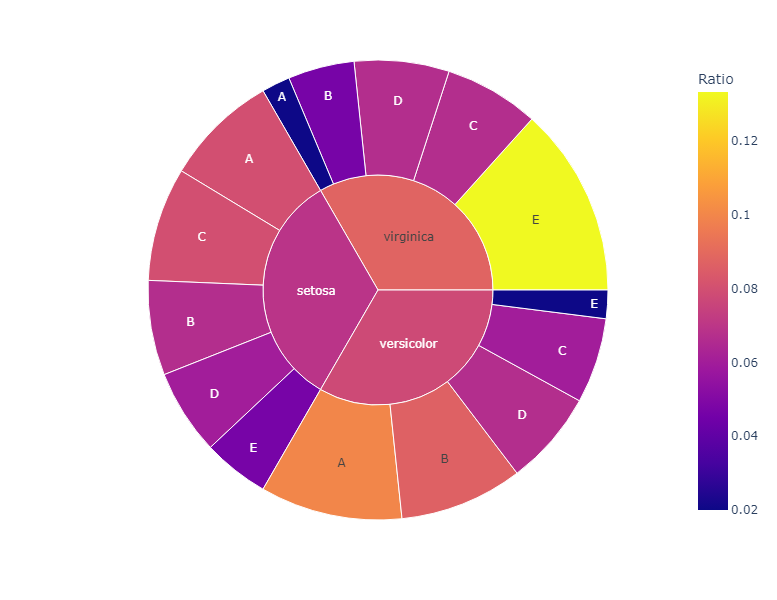

In [ ]:
# 用太阳爆炸图进行钻取，先 species，再 Category
fig = px.sunburst(prob_matrix_stacked,
                  path=['species', 'Category'],
                  values='Ratio', color='Ratio',
                  width = 600, height = 600)
fig.show()
pio.write_image(fig, '5.svg')

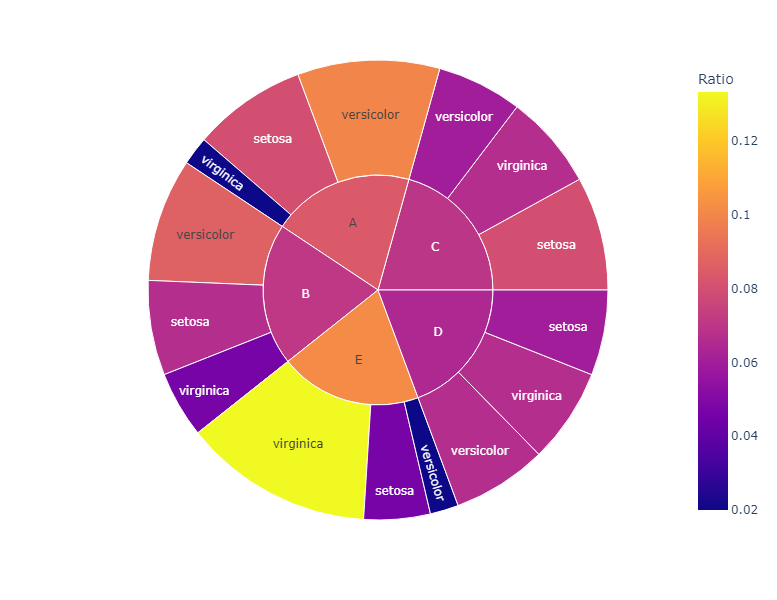

In [ ]:
# 用太阳爆炸图进行钻取，先 Category，再 species
fig = px.sunburst(prob_matrix_stacked,
                  path=['Category', 'species'],
                  values='Ratio', color='Ratio',
                  width = 600, height = 600)
fig.show()
pio.write_image(fig, '6.svg')

In [ ]:
# 再增加一层钻取维度
labels = ["{0} - {1} cm".format(i, i+1) for i in range(4, 8)]
df["sepal_length_bins"] = pd.cut(df.sepal_length, range(4, 9),
                                 right=False, labels=labels)

In [ ]:
# sepal_length_bins_counts

NameError: name 'sepal_length_bins_counts' is not defined

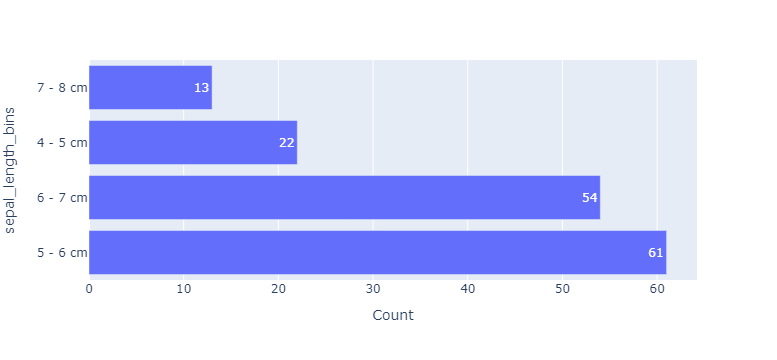

In [ ]:
# 可视化第三维度样本计数
sepal_length_bins_counts = df["sepal_length_bins"].value_counts()
sepal_length_bins_counts = pd.DataFrame({
    'sepal_length_bins':sepal_length_bins_counts.index,
    'Count':sepal_length_bins_counts.values})

fig = px.bar(sepal_length_bins_counts,
             x = 'Count', y = 'sepal_length_bins',
             orientation = 'h', text_auto=True)
fig.show()
pio.write_image(fig, '9.svg')

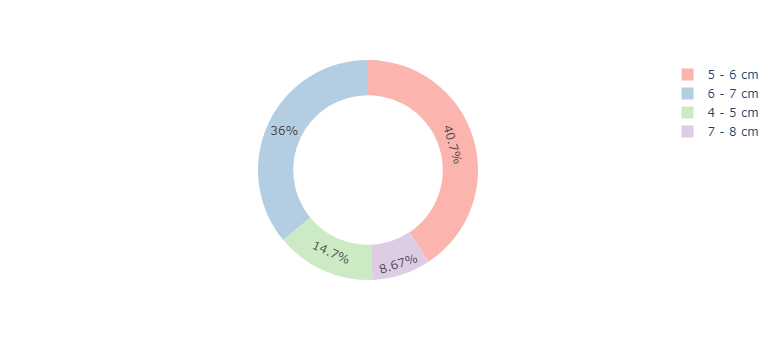

In [ ]:
# 可视化第三维度样本比例
fig = px.pie(sepal_length_bins_counts,
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             values='Count', names='sepal_length_bins')
fig.update_traces(hole=.68)
fig.show()
pio.write_image(fig, '10.svg')

In [ ]:
df.sepal_length.mean()

5.843333333333334

In [ ]:
# 计算三个维度转取的比例 (概率）值
dims = ['species','Category','sepal_length_bins']

prob_matrix_by_3 = df.groupby(dims)['sepal_length'].apply(
    lambda x: x.count()/len(df))
prob_matrix_by_3

species     Category  sepal_length_bins
setosa      A         4 - 5 cm             0.073333
                      5 - 6 cm             0.006667
                      6 - 7 cm                  NaN
                      7 - 8 cm                  NaN
            B         4 - 5 cm             0.053333
                      5 - 6 cm             0.013333
                      6 - 7 cm                  NaN
                      7 - 8 cm                  NaN
            C         4 - 5 cm             0.006667
                      5 - 6 cm             0.073333
                      6 - 7 cm                  NaN
                      7 - 8 cm                  NaN
            D         4 - 5 cm                  NaN
                      5 - 6 cm             0.060000
                      6 - 7 cm                  NaN
                      7 - 8 cm                  NaN
            E         4 - 5 cm                  NaN
                      5 - 6 cm             0.046667
                      6 

In [ ]:
prob_matrix_by_3 = prob_matrix_by_3.reset_index()
prob_matrix_by_3

,species,Category,sepal_length_bins,sepal_length
0,setosa,A,4 - 5 cm,0.073333
1,setosa,A,5 - 6 cm,0.006667
2,setosa,A,6 - 7 cm,NaN
3,setosa,A,7 - 8 cm,NaN
4,setosa,B,4 - 5 cm,0.053333
5,setosa,B,5 - 6 cm,0.013333
6,setosa,B,6 - 7 cm,NaN
7,setosa,B,7 - 8 cm,NaN
8,setosa,C,4 - 5 cm,0.006667
9,setosa,C,5 - 6 cm,0.073333


In [ ]:
prob_matrix_by_3.rename(columns = {'sepal_length':'Ratio'},
                        inplace = True)

In [ ]:
prob_matrix_by_3

,species,Category,sepal_length_bins,Ratio
0,setosa,A,4 - 5 cm,0.073333
1,setosa,A,5 - 6 cm,0.006667
2,setosa,A,6 - 7 cm,NaN
3,setosa,A,7 - 8 cm,NaN
4,setosa,B,4 - 5 cm,0.053333
5,setosa,B,5 - 6 cm,0.013333
6,setosa,B,6 - 7 cm,NaN
7,setosa,B,7 - 8 cm,NaN
8,setosa,C,4 - 5 cm,0.006667
9,setosa,C,5 - 6 cm,0.073333


In [ ]:
# 用太阳爆炸图进行钻取，先 Category，再 species，最后sepal_length_bins
fig = px.sunburst(prob_matrix_by_3,
                  path=dims,
                  values='Ratio',
                  width = 600, height = 600)
fig.show()
pio.write_image(fig, '7.svg')

In [ ]:
# 平行坐标图，分类数据关系图
dims_2 = ['species','sepal_length_bins','Category']

fig = px.parallel_categories(df,
                             dimensions = dims_2,
                             width = 800, height = 500)
fig.show()
pio.write_image(fig, '1.svg')

In [ ]:
# 将species分类转为数值
df["species_numerical"] = df["species"].map(
    {"setosa": 0, "versicolor": 1, "virginica": 2})
cmap = px.colors.sequential.Plotly3
# 可视化
fig = px.parallel_categories(df, dimensions = dims_2,
                             color = "species_numerical",
                             color_continuous_scale = cmap,
                             width = 800, height = 500)
fig.show()
pio.write_image(fig, '1.svg')

In [ ]:
# 对 Category 比例值在 species 维度上钻取
fig = px.bar(prob_matrix,
             template = "plotly_white",orientation = 'h',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600, height=300, text_auto = '.2f')
fig.show()
pio.write_image(fig, '8.svg')

In [ ]:
# 对 species 比例值在 Category 维度上钻取
fig = px.bar(prob_matrix.T,
             template = "plotly_white",orientation = 'h',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600, height=300, text_auto = '.2f')
fig.show()
pio.write_image(fig, '9.svg')

In [ ]:
# 计算Category中species的比例
ratio_species_in_category = pd.crosstab(index = df['Category'],
                                        columns = df['species'],
                                        normalize = 'index')

In [ ]:
# ratio_species_in_category.plot.bar(stacked = True)
# plt.savefig('category, stacked bar.svg')

In [ ]:
fig = px.bar(ratio_species_in_category,
             template = "plotly_white",orientation = 'h',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600, height=300, text_auto = '.2f')
fig.show()
pio.write_image(fig, '计算Category中species的比例.svg')

In [ ]:
ratio_species_in_category

In [ ]:
ratio_species_in_category.to_csv('ratio_species_in_category.csv')

In [ ]:
# 计算species中Category的比例
ratio_category_in_species = pd.crosstab(index = df['species'],
                                        columns = df['Category'],
                                        normalize = 'index')

In [ ]:
pd.crosstab(index = df['species'],
            columns = df['Category'],
            normalize = 'columns')

In [ ]:
ratio_category_in_species.to_csv('ratio_category_in_species.csv')

In [ ]:
fig = px.bar(ratio_category_in_species,
             template = "plotly_white",orientation = 'h',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600, height=300, text_auto = '.2f')
fig.show()
pio.write_image(fig, '计算species中Category的比例.svg')

In [ ]:
# pd.crosstab(index = df['Category'], columns = df['species'], normalize = 'columns').T.plot.barh(stacked = True)
# plt.savefig('species, stacked bar.svg')

In [ ]:
# freq_matrix.sum(axis = 0)

In [ ]:
# freq_matrix.sum(axis = 1)

In [ ]:
# df.columns

In [ ]:
# df.groupby(['species', 'Category'])['sepal_width'].mean()

In [ ]:
# df.groupby(['Category'])['petal_length'].mean()

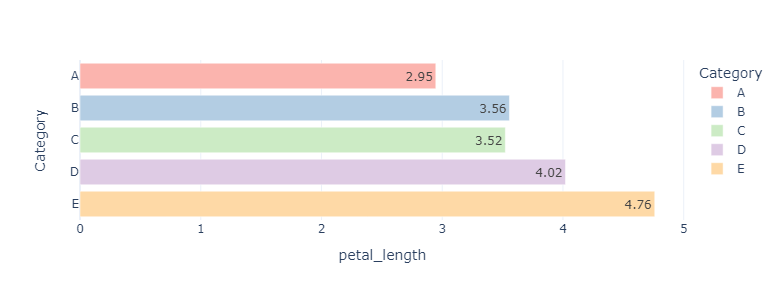

In [ ]:
# 分别计算每个子类 (Category) petal_length均值
petal_length_mean_by_ctgr = df.groupby([
    'Category'])['petal_length'].mean().reset_index()
fig = px.bar(petal_length_mean_by_ctgr,
             x = 'petal_length', y = 'Category',
             color = 'Category',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600, height=300,
             text_auto = '.2f', orientation = 'h',
             template = "plotly_white")
fig.show()
# pio.write_image(fig, 'petal_length_mean, Category.svg')

In [ ]:
# 创建交叉指标，计算petal_length平均值
# 行：Category；列：species
pd.crosstab(index = df.Category, columns = df.species,
            values=df.petal_length, aggfunc='mean')

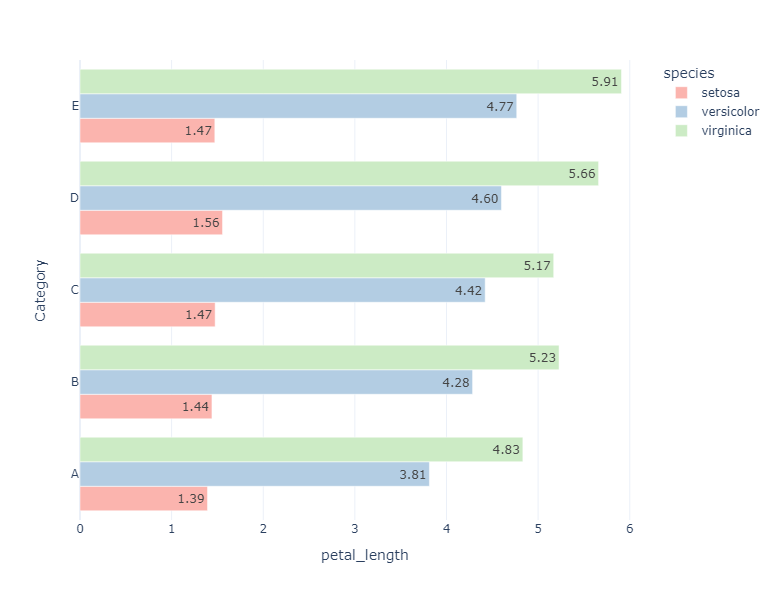

In [ ]:
# 分别计算每个子类 (x Category y species) petal_length均值
petal_length_mean_by_species_ctgr = df.groupby([
    'species', 'Category'])['petal_length'].mean().reset_index()
fig = px.bar(petal_length_mean_by_species_ctgr,
             x = 'petal_length', y = 'Category',
             color = 'species', barmode = 'group',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600, height=600,
             text_auto = '.2f', orientation = 'h',
             template = "plotly_white")
fig.show()
# pio.write_image(fig, 'petal_length_mean, Category to Species.svg')

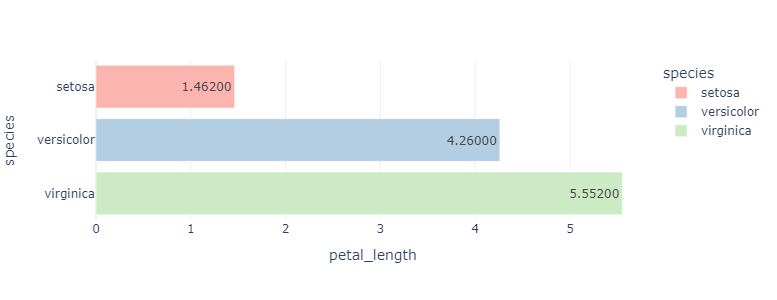

In [ ]:
# 分别计算每个子类 (species) petal_length均值
petal_length_mean_by_species = df.groupby([
    'species'])['petal_length'].mean().reset_index()
fig = px.bar(petal_length_mean_by_species,
             x = 'petal_length', y = 'species',
             color = 'species',
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             width=600, height=300,
             text_auto = '.5f', orientation = 'h',
             template = "plotly_white")
fig.show()
# pio.write_image(fig, 'petal_length_mean, species.svg')

In [ ]:
pd.crosstab(index = df.Category, columns = df.species,
            values=df.petal_length, aggfunc='mean')

species,setosa,versicolor,virginica
Category,,,
A,1.391667,3.813333,4.833333
B,1.440000,4.284615,5.228571
C,1.475000,4.422222,5.170000
D,1.555556,4.600000,5.660000
E,1.471429,4.766667,5.910000


In [ ]:
petal_length_mean_by_species.mean()

C:\Users\james\AppData\Local\Temp\ipykernel_21784\2726099988.py:1: FutureWarning:

The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.



petal_length    3.758
dtype: float64

In [ ]:
# 创建交叉指标，计算petal_length平均值
# 行：species；列：Category
pd.crosstab(index = df.species, columns = df.Category,
            values=df.petal_length, aggfunc='mean')

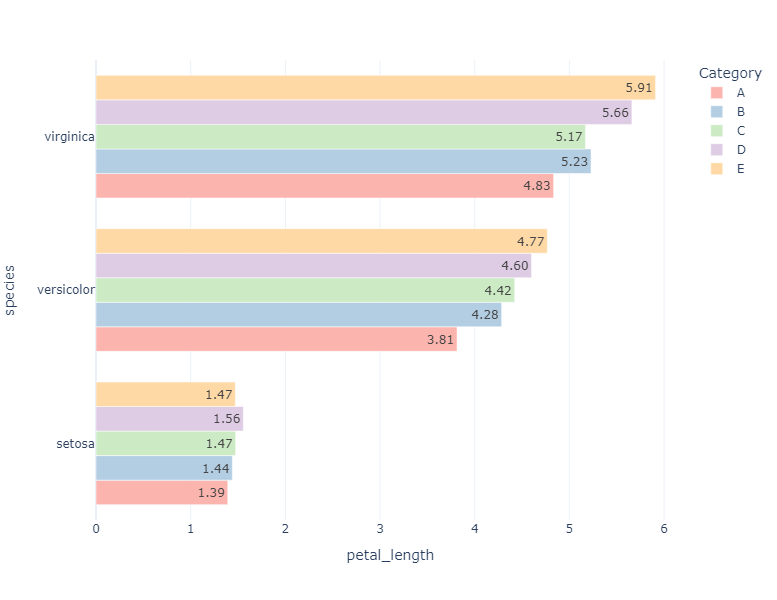

In [ ]:
# 可视化petal_length均值，先species分类再Category分类
fig = px.bar(petal_length_mean_by_species_ctgr,
             x = 'petal_length', y = 'species',
             color = 'Category', barmode = 'group',
             text_auto = '.2f', orientation = 'h',
             width=600, height=600,
             color_discrete_sequence=px.colors.qualitative.Pastel1,
             template = "plotly_white")
fig.show()
# pio.write_image(fig, 'petal_length_mean, Species to Category.svg')

In [ ]:
sns.heatmap(pd.crosstab(index = [df.species, df.sepal_length_bins],
            columns = df.Category,
            values=df.petal_length, aggfunc=['mean', 'count']),
            cmap = 'Blues')

In [ ]:
pd.crosstab(index = [df.species, df.sepal_length_bins],
            columns = df.Category,
            values=df.petal_length, aggfunc=['mean'])

In [ ]:
px.imshow(prob_matrix, text_auto='.3f')

In [ ]:
# 计算花萼长度条件均值；
# 行：sepal_length_bins
# 列：species > Category
pd.crosstab(index = df.sepal_length_bins,
            columns = [df.species, df.Category],
            values=df.petal_length, aggfunc='mean')

species              setosa                                      versicolor  \
Category                  A      B         C         D         E          A   
sepal_length_bins                                                             
4 - 5 cm           1.372727  1.475  1.400000       NaN       NaN   3.300000   
5 - 6 cm           1.600000  1.300  1.481818  1.555556  1.471429   3.727273   
6 - 7 cm                NaN    NaN       NaN       NaN       NaN   4.300000   
7 - 8 cm                NaN    NaN       NaN       NaN       NaN        NaN   

species                                              virginica            \
Category                  B         C         D    E         A         B   
sepal_length_bins                                                          
4 - 5 cm                NaN       NaN       NaN  NaN       4.5       NaN   
5 - 6 cm           4.154545  4.200000  4.800000  NaN       5.0  5.050000   
6 - 7 cm           5.000000  4.485714  4.577778  4.8       5.0  5.466667   
7 - 8 cm                NaN       NaN       NaN  4.7       NaN       NaN   

species                                  
Category                  C     D     E  
sepal_length_bins                        
4 - 5 cm                NaN   NaN   NaN  
5 - 6 cm           5.100000   NaN   NaN  
6 - 7 cm           5.177778  5.45  5.56  
7 - 8 cm                NaN  6.50  6.26

In [ ]:
# 计算花萼长度条件均值；
# 行：species > Category
# 列：sepal_length_bins
pd.crosstab(index = [df.species, df.Category],
            columns = df.sepal_length_bins,
            values=df.petal_length, aggfunc='mean')

In [ ]:
# fig = px.bar(petal_length_mean_by_3dims,
#              barmode = 'group',
#              text_auto = '.2f', orientation = 'h',
#              width=600, height=600,
#              color_discrete_sequence=px.colors.qualitative.Pastel1,
#              template = "plotly_white")
# fig.show()

In [ ]:
# 交叉计数，计数
count_matrix = pd.crosstab(index = [df.species, df.Category],
            columns = df.sepal_length_bins,
            values=df.petal_length, aggfunc='count')

count_matrix = count_matrix.stack().reset_index()
count_matrix.rename(columns = {0:'count'}, inplace = True)
count_matrix = count_matrix[count_matrix['count'] != 0]
# 删除 'count' 列值为0的行

In [ ]:
count_matrix.columns

In [ ]:
# 冰柱图
fig = px.icicle(count_matrix,
                path=[px.Constant("all"), 'species', 'Category', 'sepal_length_bins'],
                values = 'count',
                color_continuous_scale='Blues',
                color = 'count',
                width = 600, height = 800)
fig.show()
pio.write_image(fig, '冰柱图.svg')

In [ ]:
# 矩形树形图
fig = px.treemap(count_matrix,
                path=[px.Constant("all"),
                      'species', 'Category', 'sepal_length_bins'],
                values = 'count',
                color_continuous_scale='Blues',
                color = 'count',
                width = 600, height = 800)
fig.show()
pio.write_image(fig, '矩形树形图.svg')